Value at Risk (VaR) Analysis for a Multi-Asset Portfolio

This project estimates 1-day Historical VaR and 1-day / 10-day Parametric VaR
for a diversified portfolio using daily return data.

Data:
- Daily returns for SPY, QQQ, AGG, GLD
- Approx. 1 year of observations

Assumption:
- Returns are already calculated and cleaned

Portfolio Weights:
- SPY: 40%
- QQQ: 25%
- AGG: 25%
- GLD: 10%

Portfolio Value: $100,000

Key Results:
- Daily portfolio volatility ≈ 0.63%

- 1-day 95% Historical VaR ≈ $1,044

- 10-day 95% Parametric VaR ≈ $3,268

Interpretation:

The 10-day 95% Parametric VaR of approximately $3,268 suggests that,
under normal market conditions, the portfolio is expected to lose no
more than this amount over a 10-day period with 95% confidence.

The comparison between Historical and Parametric VaR highlights how
different modeling assumptions (empirical distribution vs normal
distribution) can affect risk estimates.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Price_Data.csv to Price_Data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Price_Data.csv")
df.head()

,Date,SPY,QQQ,AGG,GLD
0,4/22/2026,0.010127,0.016731,0.001407,0.013246
1,4/21/2026,-0.008534,-0.003803,-0.003706,-0.036687
2,4/20/2026,0.000000,-0.003175,-0.000100,0.000000
3,4/17/2026,0.012086,0.013084,0.003719,0.013293
4,4/16/2026,0.002457,0.004816,-0.001405,-0.000863


In [ ]:
returns = df[["SPY", "QQQ", "AGG", "GLD"]]

# Keep only rows where values look like returns (small numbers)
returns = returns[(returns.abs() < 1).all(axis=1)]

In [ ]:
weights = np.array([0.40, 0.25, 0.25, 0.10])
portfolio_value = 100000

In [ ]:
returns["Portfolio"] = returns.dot(weights)
returns.head()

,SPY,QQQ,AGG,GLD,Portfolio
Date,,,,,
2025-04-24,0.021049,0.028137,0.005527,0.014556,0.018291
2025-04-25,0.007225,0.011148,0.003664,-0.010842,0.005509
2025-04-28,0.000381,-0.000317,0.002738,0.014242,0.002182
2025-04-29,0.006299,0.006604,0.002427,-0.009739,0.003804
2025-04-30,0.000397,-0.000126,-0.000908,-0.007482,-0.000848


In [ ]:
cov_matrix = returns[["SPY", "QQQ", "AGG", "GLD"]].cov()
print(cov_matrix)

          SPY       QQQ       AGG       GLD
SPY  0.000064  0.000079  0.000004  0.000012
QQQ  0.000079  0.000107  0.000004  0.000017
AGG  0.000004  0.000004  0.000007  0.000007
GLD  0.000012  0.000017  0.000007  0.000297


In [ ]:
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_std_dev = np.sqrt(portfolio_variance)

print("Portfolio Variance:", portfolio_variance)
print("Portfolio Daily Std Dev:", portfolio_std_dev)

Portfolio Variance: 3.9480199492919635e-05
Portfolio Daily Std Dev: 0.006283327103765937


In [ ]:
portfolio_returns = returns["Portfolio"]

hist_var_90 = -np.percentile(portfolio_returns, 10) * portfolio_value
hist_var_95 = -np.percentile(portfolio_returns, 5) * portfolio_value
hist_var_99 = -np.percentile(portfolio_returns, 1) * portfolio_value

print("Historical VaR 90%:", round(hist_var_90, 2))
print("Historical VaR 95%:", round(hist_var_95, 2))
print("Historical VaR 99%:", round(hist_var_99, 2))

Historical VaR 90%: 654.2
Historical VaR 95%: 1042.17
Historical VaR 99%: 1556.54


In [ ]:
z_95 = 1.645
param_var_1d = portfolio_value * portfolio_std_dev * z_95
print("1-Day Parametric VaR:", round(param_var_1d, 2))

1-Day Parametric VaR: 1033.61


In [ ]:
days = 10
param_var_10d = portfolio_value * portfolio_std_dev * z_95 * np.sqrt(days)
print("10-Day Parametric VaR:", round(param_var_10d, 2))

10-Day Parametric VaR: 3268.55


In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Portfolio Variance",
        "Portfolio Daily Std Dev",
        "Historical VaR 90%",
        "Historical VaR 95%",
        "Historical VaR 99%",
        "Parametric VaR 1-Day (95%)",
        "Parametric VaR 10-Day (95%)"
    ],
    "Value": [
        portfolio_variance,
        portfolio_std_dev,
        hist_var_90,
        hist_var_95,
        hist_var_99,
        param_var_1d,
        param_var_10d
    ]
})

summary

,Metric,Value
0,Portfolio Variance,0.000039
1,Portfolio Daily Std Dev,0.006283
2,Historical VaR 90%,654.198266
3,Historical VaR 95%,1042.170756
4,Historical VaR 99%,1556.541402
5,Parametric VaR 1-Day (95%),1033.607309
6,Parametric VaR 10-Day (95%),3268.553301


In [ ]:
summary.to_csv("var_summary.csv", index=False)

In [ ]:
files.download("var_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

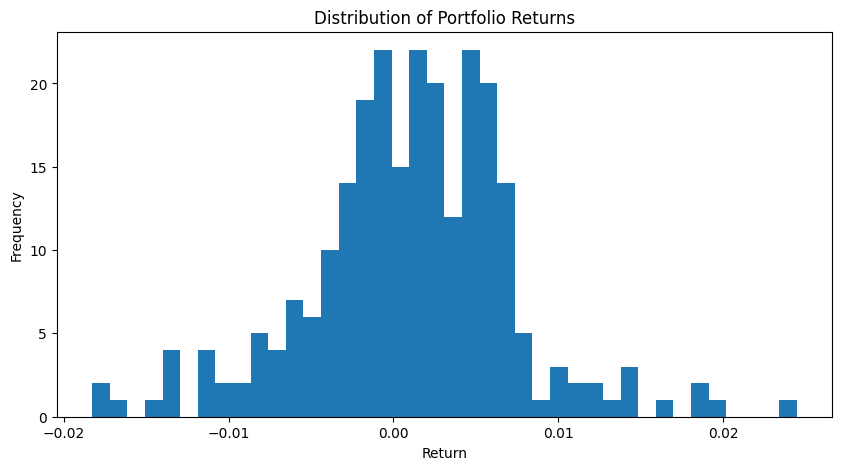

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=40)
plt.title("Distribution of Portfolio Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

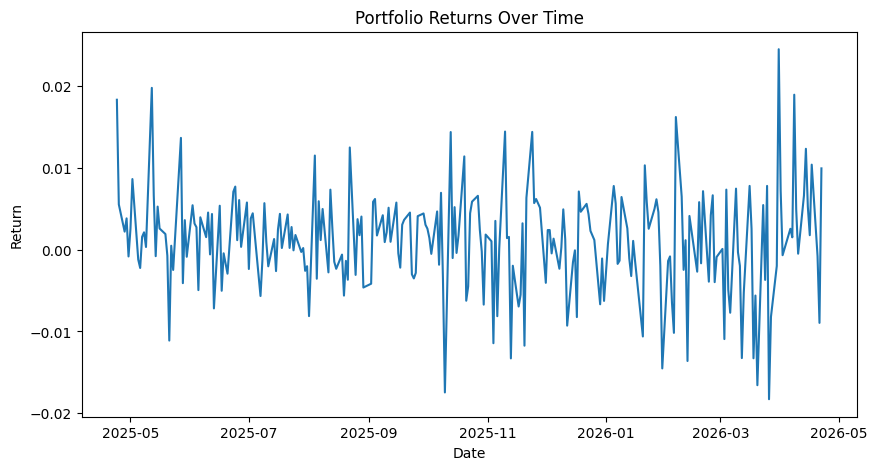

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_returns.index, portfolio_returns.values)
plt.title("Portfolio Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

This project calculates Value at Risk (VaR) for a multi-asset portfolio using both Historical and Parametric methods based on daily return data.

In [ ]:
summary.to_csv("var_summary.csv", index=False)

In [ ]:
from google.colab import files
files.download("var_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>